In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# How much carbon dioxide dissolves in toluene?

This notebook works **Illustration 11.1-2**: the solubility of carbon dioxide in liquid
toluene at 25 °C under 1.013 bar of CO₂ partial pressure, from the Peng-Robinson
equation of state.

**Why the equation of state, when Section 11.1 already has a correlation.** Illustration
11.1-1 answers the same question with the Prausnitz-Shair correlation and regular
solution theory and gets 0.0077 mole fraction. This one gets 0.0128 — nearly double. The
chapter's own verdict is that "given the inaccuracy of both methods, this difference is
not unreasonable," and that is worth taking seriously rather than reading past: gas
solubility is a hard prediction, and two respectable routes disagree by a factor of two.

**What makes it awkward to compute**, and why the illustration prints a table instead of
an answer: the specification is a *partial* pressure. You cannot start from it. What the
equation of state does is take a liquid composition and return the bubble pressure and
the vapor composition; the CO₂ partial pressure $y_1 P$ comes out at the *end*. So the
printed solution sweeps composition, tabulates $y_1P$, and reads back the composition
that gives 1.013 bar. A root finder does that in one line, and this notebook does it both
ways.

⚠️ **And the whole answer turns on one estimated number.** The binary interaction
parameter $k_{12}$ for CO₂ + toluene is not in Table 9.4-1; the illustration estimates
0.09 by splitting the difference between CO₂-benzene (0.077) and CO₂-*n*-heptane (0.10).
Section 11.1 does not say what that estimate costs, so the last part of this notebook
measures it.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from thermo.pr_mixture import PRMixture
from thermo.charts import use_book_style

use_book_style()

BAR = 1e5
T = 298.15
P_CO2 = 1.013 * BAR             # the specified CO2 partial pressure
K12 = 0.09                      # estimated, not tabulated

mix = PRMixture.from_database(["carbon dioxide", "toluene"],
                              kij=[[0.0, K12], [K12, 0.0]])
for c, name in zip(mix.components, ("carbon dioxide", "toluene")):
    print(f"  {name:16s} Tc = {c.Tc:6.1f} K   Pc = {c.Pc / BAR:5.2f} bar   "
          f"omega = {c.omega:.3f}")

  carbon dioxide   Tc =  304.1 K   Pc = 73.80 bar   omega = 0.239
  toluene          Tc =  591.8 K   Pc = 41.00 bar   omega = 0.263



## The printed table

Nine liquid compositions, each one a bubble-pressure calculation: given $x$ and $T$, find
the $P$ and $y$ that satisfy $x_i \phi_i^{\rm L}(x, T, P) = y_i \phi_i^{\rm V}(y, T, P)$
for both species. The last column, $y_1 P$, is the CO₂ partial pressure — the quantity the
problem statement actually fixes.


In [3]:
# SIS Illustration 11.1-2's table: x_CO2, P_tot (bar), y_CO2
printed = [(0.001, 0.11, 0.6579), (0.002, 0.20, 0.7915), (0.004, 0.36, 0.8834),
           (0.006, 0.51, 0.9189), (0.008, 0.67, 0.9378), (0.010, 0.83, 0.9495),
           (0.0125, 1.03, 0.9590), (0.013, 1.07, 0.9605), (0.015, 1.23, 0.9655)]

print(f"  {'x_CO2':>7s}   {'P (bar)':>15s}   {'y_CO2':>15s}   {'y_CO2 P (bar)':>15s}")
print(f"  {'':>7s}   {'SIS   computed':>15s}   {'SIS   computed':>15s}   "
      f"{'SIS   computed':>15s}")
for x, Pb, yb in printed:
    P, y = mix.bubble_pressure([x, 1 - x], T)
    print(f"  {x:7.4f}   {Pb:6.2f}{P / BAR:9.3f}   {yb:6.4f}{y[0]:9.4f}   "
          f"{yb * Pb:6.3f}{y[0] * P / BAR:9.3f}")

    x_CO2           P (bar)             y_CO2     y_CO2 P (bar)
             SIS   computed    SIS   computed    SIS   computed
   0.0010     0.11    0.120   0.6579   0.6659    0.072    0.080
   0.0020     0.20    0.200   0.7915   0.7992    0.158    0.160
   0.0040     0.36    0.360   0.8834   0.8881    0.318    0.319
   0.0060     0.51    0.520   0.9189   0.9223    0.469    0.479
   0.0080     0.67    0.680   0.9378   0.9404    0.628    0.639
   0.0100     0.83    0.840   0.9495   0.9516    0.788    0.799
   0.0125     1.03    1.040   0.9590   0.9608    0.988    0.999
   0.0130     1.07    1.080   0.9605   0.9622    1.028    1.039
   0.0150     1.23    1.240   0.9655   0.9670    1.188    1.199



Every total pressure lands within 0.01 bar of the printed one — one unit in the last digit
the table carries — and every vapor composition within 0.002 except at the most dilute
point. ⓘ The small systematic offset is in the *solvent*: fitting both columns to
$P = P_0 + s\,x$ gives an intercept of 0.036 bar for the printed table and 0.040 bar for
these, and 0.040 bar is exactly what Peng-Robinson gives for the vapor pressure of pure
toluene at 25 °C.

## The answer, without the table

The illustration reads its answer off the table by interpolating between the rows at
$x = 0.0125$ and $x = 0.013$. Solving for it directly is the same calculation with the
composition as the unknown.


In [4]:
def partial_pressure(x1, k12=K12, solvent="toluene"):
    """CO2 partial pressure over a liquid of composition x1, from the PR EOS."""
    m = PRMixture.from_database(["carbon dioxide", solvent],
                                kij=[[0.0, k12], [k12, 0.0]])
    P, y = m.bubble_pressure([x1, 1 - x1], T)
    return y[0] * P

def solubility(k12=K12, solvent="toluene"):
    """The liquid composition whose CO2 partial pressure is 1.013 bar."""
    return brentq(lambda x: partial_pressure(x, k12, solvent) - P_CO2,
                  1e-6, 0.05, xtol=1e-12)

x_sol = solubility()
print(f"  solubility of CO2 in toluene:  x = {x_sol:.5f}    (SIS 11.1-2: 0.0128)")
print(f"  check: partial pressure there  {partial_pressure(x_sol) / BAR:.4f} bar")
print(f"\n  Illustration 11.1-1, same question by regular solution theory:  0.0077")

  solubility of CO2 in toluene:  x = 0.01268    (SIS 11.1-2: 0.0128)
  check: partial pressure there  1.0130 bar

  Illustration 11.1-1, same question by regular solution theory:  0.0077



## What the estimated $k_{12}$ costs

The illustration's Comment gives the number for $k_{12} = 0$ — 0.0221, which is Problem
11.1-6 — and that is the whole story in two points: **an interaction parameter guessed to
within 0.09 moves the predicted solubility by a factor of 1.7.** Sweeping it turns two
points into a curve, and the curve is the honest statement of how much this prediction is
worth.

⚠️ It also shows something that is easy to say and hard to feel: $k_{12}$ is a *fitted*
parameter. When it is available from data the prediction is respectable; when it is
estimated from a chemical neighbor, the uncertainty in the answer is set by the estimate,
not by the equation of state.


  toluene, k12 = 0.00:  0.0219   (SIS Comment / Problem 11.1-6: 0.0221)
  toluene, k12 = 0.09:  0.0127   (SIS: 0.0128)


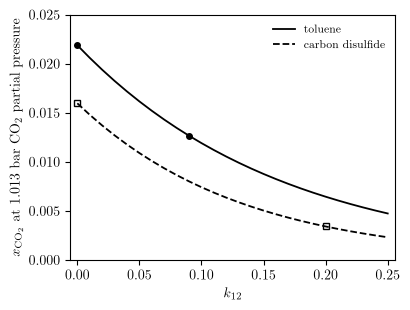

In [5]:
ks = np.linspace(0.0, 0.25, 26)
tol_curve = np.array([solubility(k) for k in ks])
cs2_curve = np.array([solubility(k, "carbon disulfide") for k in ks])

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.plot(ks, tol_curve, "k-", lw=1.3, label="toluene")
ax.plot(ks, cs2_curve, "k--", lw=1.3, label="carbon disulfide")
ax.plot([0.0, K12], [solubility(0.0), x_sol], "ko", ms=4)
ax.plot([0.0, 0.20], [solubility(0.0, "carbon disulfide"),
                      solubility(0.20, "carbon disulfide")], "ks", ms=4, mfc="none")
ax.set_xlabel(r"$k_{12}$")
ax.set_ylabel(r"$x_{\rm CO_2}$ at 1.013 bar CO$_2$ partial pressure")
ax.set_xlim(-0.006, 0.256); ax.set_ylim(0, 0.025)
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

print(f"  toluene, k12 = 0.00:  {solubility(0.0):.4f}   (SIS Comment / Problem 11.1-6: 0.0221)")
print(f"  toluene, k12 = 0.09:  {x_sol:.4f}   (SIS: 0.0128)")


## Carbon disulfide, where the estimate is not available at all

The Comment then does the same calculation for CO₂ in carbon disulfide, where Table 9.4-1
has no entry and no chemical neighbor to borrow from either. With $k_{12} = 0$ the
prediction is **five times the measured solubility**. The illustration then quotes a value
of $k_{12}$ that brings it into "excellent agreement with experiment."

⭐ That number is printed inside an equation, so it is worth recovering by asking the
question backwards: *what $k_{12}$ reproduces 3.4 × 10⁻³?*


In [6]:
print(f"  CS2, k12 = 0:  x = {solubility(0.0, 'carbon disulfide'):.5f}"
      f"   (SIS Comment / Problem 11.1-7: 0.0159)")

k_star = brentq(lambda k: solubility(k, "carbon disulfide") - 3.4e-3, 0.1, 0.3, xtol=1e-8)
print(f"  the k12 that gives 3.4e-3:  {k_star:.4f}   (SIS prints 0.2)")
print(f"  measured solubility, then:  3.4e-3, which is {0.0159 / 3.4e-3:.1f}x smaller "
      f"than the k12 = 0 prediction")

  CS2, k12 = 0:  x = 0.01598   (SIS Comment / Problem 11.1-7: 0.0159)


  the k12 that gives 3.4e-3:  0.2012   (SIS prints 0.2)
  measured solubility, then:  3.4e-3, which is 4.7x smaller than the k12 = 0 prediction



⛔ **Read that last calculation for what it is.** A $k_{12}$ chosen so that the model
reproduces one measurement is a *fit to that measurement*, not a prediction of it. The
sentence "in excellent agreement with experiment" is true and it is describing a
one-parameter fit to a single point. The honest summary of this illustration is:

| | | |
|---|---|---|
| CO₂ + toluene, $k_{12}$ estimated from neighbors | 0.0128 | a prediction, uncertain by roughly a factor of two |
| CO₂ + toluene, $k_{12} = 0$ | 0.0221 | what you get with no information at all |
| CO₂ + CS₂, $k_{12} = 0$ | 0.0159 | wrong by a factor of five |
| CO₂ + CS₂, $k_{12} = 0.20$ | 0.0034 | correct, because it was fitted to be |

and that is a fair picture of where equation-of-state gas-solubility prediction stands.

## Your turn

1. **Problem 11.1-6** is the $k_{12} = 0$ toluene case and **Problem 11.1-7** the CS₂ pair;
   both are already above. Do them for a third solvent from Table 9.4-1 that *does* have a
   tabulated CO₂ parameter, and compare the spread.
2. The illustration works at one temperature. Repeat it from 0 °C to 60 °C and plot the
   solubility. Does CO₂ in toluene follow Fig. 11.1-3's pattern of decreasing solubility
   with temperature, and what does Eq. 11.1-17 say it should do?
3. Convert your answer to a Henry's law constant, $H = \lim_{x\to0} \bar{f}_1/x_1$, using
   the machinery of Eq. 11.1-9. Is 1.013 bar low enough for Henry's law to hold — that is,
   is $y_1P$ linear in $x_1$ over the table's range?
4. The illustration assumes toluene is involatile enough to ignore. It is not: check what
   fraction of the total pressure is toluene at each row of the table, and at which
   composition that stops mattering.
5. Illustration 11.1-1 answers the same question with regular solution theory and gets
   0.0077. Which one would you defend, and what measurement would settle it?
